# Airbnb Tokyo Price Prediction with LightGBM

## 基本情報

- 主題: LightGBM
- 作成者: 荒田禎之
- 位置づけ: LightGBM を用いた予測モデルの構築
- 使用データ: Inside Airbnb Tokyo listings
- 分析課題: Airbnb Tokyo listings データを使い、数値・カテゴリ変数から $\log(\mathrm{price})$ を LightGBM で予測
- 到達目標:
  - 数値・カテゴリ変数だけを用いた LightGBM モデルを構築する
  - LightGBM でカテゴリ変数を扱うための `category` dtype の使い方を理解する

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

`inside_airbnb_tokyo_eda_colab.ipynb` で使っている Inside Airbnb Tokyo の listings データを使う。テキスト変数は使わず、宿泊人数、寝室数、レビュー指標、緯度・経度などの数値変数と、部屋タイプ、物件タイプ、エリア、予約可否などのカテゴリ変数から $\log(\mathrm{price})$ を予測する。

LightGBM は pandas の `category` dtype を通じてカテゴリ変数を扱えるため、One-hot encoding は行わない。カテゴリ列の欠損は `__MISSING__` に置換してから `category` dtype に変換する。


In [1]:
# LightGBM が未インストールの場合のみ、次の行のコメントを外して実行してください。
# !pip install lightgbm

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")


## 2. データの読み込み

Inside Airbnb Tokyo の listings URL から直接読み込む。下記のコードでは、ローカルに csv ファイルがある場合も想定してコードが複雑になっているが、その点は気にせず、コードを実行すればURLからそのままダウンロードする。

直接読み込む場合、`price` は `$12,345` のような文字列で入っていることがあるため、数値に変換する。


In [ ]:
DATA_URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2026-06-30/data/listings.csv.gz"
filename = "airbnb_tokyo_model_ready_eda.csv"
candidate_paths = [Path(filename), Path("data") / filename, Path("notebook") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

numeric_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "host_listings_count",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_is_superhost",
    "instant_bookable",
]

if csv_path is not None:
    df = pd.read_csv(csv_path)
    print(f"Loaded local modeling data: {csv_path.resolve()}")
else:
    selected_cols = ["price"] + numeric_features + categorical_features
    raw = pd.read_csv(DATA_URL, compression="gzip", low_memory=False)
    available_cols = [col for col in selected_cols if col in raw.columns]
    df = raw[available_cols].copy()
    print(f"Loaded Inside Airbnb data from: {DATA_URL}")

print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())


## 3. 説明変数と目的変数の作成

目的変数は $\log(\mathrm{price})$ とする。`airbnb_tokyo_model_ready_eda.csv` に含まれる `price_num` があればそれを使い、直接読み込んだデータでは `price` から数値を作る。

`number_of_reviews >= 5` の listing に絞り、そのサンプル内で `price_num` の下位0.1%と上位0.1%を除外する。今回のモデルではテキスト変数を使わず、利用可能な数値列とカテゴリ列だけを説明変数にする。


In [ ]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    x = re.sub(r"[^0-9.]", "", str(x))
    return float(x) if x else np.nan

if "price_num" not in df.columns:
    if "price" not in df.columns:
        raise KeyError("`price_num` または `price` が必要です。")
    df["price_num"] = df["price"].apply(clean_price)

available_numeric_features = [col for col in numeric_features if col in df.columns]
available_categorical_features = [col for col in categorical_features if col in df.columns]
feature_columns = available_numeric_features + available_categorical_features

if "number_of_reviews" not in df.columns:
    raise KeyError("`number_of_reviews` が必要です。")
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")

base_mask = (
    df["price_num"].notna()
    & (df["price_num"] > 0)
    & df["number_of_reviews"].notna()
    & (df["number_of_reviews"] >= 5)
)
price_lower = df.loc[base_mask, "price_num"].quantile(0.001)
price_upper = df.loc[base_mask, "price_num"].quantile(0.999)
sample_mask = base_mask & df["price_num"].between(price_lower, price_upper)

print(f"Rows with positive price and number_of_reviews >= 5: {base_mask.sum():,}")
print(f"Price filter: {price_lower:,.0f} <= price_num <= {price_upper:,.0f}")
print(f"Rows after price 0.1% tail filtering: {sample_mask.sum():,}")

model_data = df.loc[
    sample_mask,
    feature_columns + ["price_num"],
].copy()

for column in available_numeric_features:
    model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

for column in available_categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype("category")

X = model_data[feature_columns]
y = np.log(model_data["price_num"])

print(f"Rows used for modeling: {len(model_data):,}")
print(f"Numeric features: {available_numeric_features}")
print(f"Categorical features: {available_categorical_features}")
display(X.head())
display(y.describe().rename("log_price").to_frame())


## 4. LightGBM の学習

データの80%を訓練用、10%を検証用、10%をテスト用に分割する。検証データは early stopping のみに使い、最終指標はテストデータで計算する。

LightGBM にはカテゴリ列名を `categorical_feature` として渡す。カテゴリ列はすでに `category` dtype に変換しているため、One-hot encoding せずに学習できる。


In [4]:
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train):,}, validation: {len(X_valid):,}, test: {len(X_test):,}")

model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=3_000,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    categorical_feature=available_categorical_features,
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=100)],
)

print(f"Best iteration: {model.best_iteration_:,}")


Train: 18,796, validation: 2,349, test: 2,350
Training until validation scores don't improve for 100 rounds
[100]	valid_0's rmse: 0.335725
[200]	valid_0's rmse: 0.316591
[300]	valid_0's rmse: 0.310881
[400]	valid_0's rmse: 0.306776
[500]	valid_0's rmse: 0.303713
[600]	valid_0's rmse: 0.301816
[700]	valid_0's rmse: 0.30026
[800]	valid_0's rmse: 0.298937
[900]	valid_0's rmse: 0.298187
[1000]	valid_0's rmse: 0.29742
[1100]	valid_0's rmse: 0.296515
[1200]	valid_0's rmse: 0.295895
[1300]	valid_0's rmse: 0.295651
[1400]	valid_0's rmse: 0.295371
[1500]	valid_0's rmse: 0.295093
[1600]	valid_0's rmse: 0.294883
[1700]	valid_0's rmse: 0.294572
[1800]	valid_0's rmse: 0.294509
Early stopping, best iteration is:
[1716]	valid_0's rmse: 0.294454
Best iteration: 1,716


## 5. テストデータでの評価

モデル選択に使っていないテストデータから log 価格を予測する。RMSE は大きな誤差を強く評価し、MAE は平均的な絶対誤差、$R^2$ は log 価格の分散をモデルがどの程度説明したかを表す。最後に実測値と予測値を指数変換して価格へ戻し、価格単位の MAE も計算する。


In [5]:
y_pred = model.predict(X_test)

metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, JPY)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))


,value
RMSE (log price),0.312321
MAE (log price),0.212474
R2 (log price),0.745218
"MAE (price, JPY)",6492.102526


### 予測値と残差の可視化

左図では実際の log 価格と予測 log 価格を比較し、点が45度の破線に近いほど正確な予測であることを示す。右図では残差を「実際値 − 予測値」として計算し、その分布を確認する。


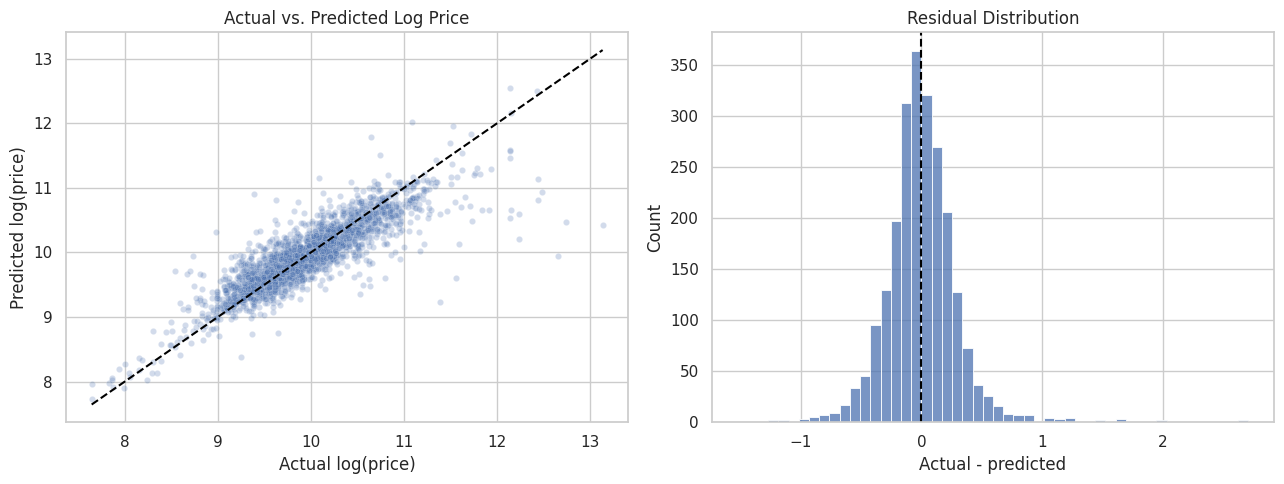

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()


## 6. 特徴量重要度

学習済み LightGBM から各入力列の特徴量重要度を取得し、高い順に表で表示する。さらに横棒グラフにして、数値変数やカテゴリ変数がモデルの分岐へどの程度寄与したかを比較する。


,importance
availability_365,13887
latitude,12181
longitude,11849
reviews_per_month,11618
host_listings_count,11159
number_of_reviews,10354
review_scores_rating,9353
beds,5037
accommodates,4645
neighbourhood_cleansed,3413


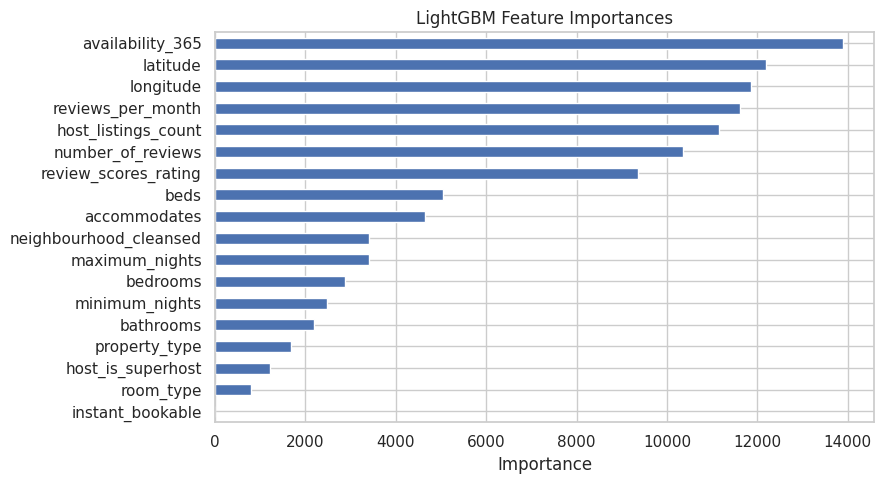

In [7]:
feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=feature_columns,
        name="importance",
    )
    .sort_values(ascending=False)
)
display(feature_importance.to_frame())

plt.figure(figsize=(9, 5))
feature_importance.sort_values().plot.barh()
plt.title("LightGBM Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 7. 予測結果の例

テストデータの先頭10件について、各特徴量、実際の価格、予測した価格を並べて表示する。log 価格を指数変換して元の価格尺度に戻すことで、集約指標だけでは分からない個別予測のずれを目視確認できる。


In [ ]:
prediction_examples = X_test.head(10).copy()
prediction_examples["actual_price"] = np.exp(y_test.head(10))
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)
